<a href="https://colab.research.google.com/github/duddet01/Learning_ai/blob/main/Backprop_micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
  def __init__(self,data, _children=(),_op='',label=''):
    self.data=data
    self._prev=set(_children)
    self._op= _op
    self.label=label
    self.grad=0.0
    self._backpropagate = lambda : None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data + other.data,(self,other),'+')

    def _backpropagate():
        self.grad+=1.0*out.grad   #we need to accumulate gradients
        other.grad+=1.0*out.grad
    out._backpropagate=_backpropagate
    return out

  def __sub__(self,other):
    return self+(-other)

  def __neg__(self):
    return self*(-1)


  def __mul__(self,other):
    other=other if isinstance(other,Value) else Value(other)
    out=Value(self.data * other.data,(self,other),'*')
    def _backpropagate():
        self.grad+=other.data*out.grad
        other.grad+=self.data*out.grad
    out._backpropagate=_backpropagate
    return out

  def __rmul__(self,other):
      return self * other

  def tanh(self):
    n=self.data
    t=(math.exp(2*n)-1)/(math.exp(2*n)+1)
    out = Value(t,(self,),'tanh')
    def _backpropagate():
        self.grad+=(1-t**2)*out.grad
    out._backpropagate=_backpropagate # Assign the _backpropagate function to the out object
    return out


  def exp(self):
    x=self.data
    out = Value(math.exp(x),(self,),'exp')
    def _backpropagate():
        self.grad+=out.data*out.grad
    out._backpropagate=_backpropagate # Assign the _backpropagate function to the out object
    return out


  def __pow__(self,other):
    assert isinstance(other,(int,float)),"only int/float powers"
    out=Value(self.data**other,(self,),f'**{other}')

    def _backpropagate():
      self.grad+=other*self.data**(other-1)*out.grad
    out._backpropagate=_backpropagate
    return out


  def __truediv__(self,other):
      return self*other**-1


  def backward(self):
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backpropagate()





In [3]:
a=Value(3.0)
b=2*a
a-b

Value(data=-3.0)

In [4]:

a=Value(2.0,label='a')
b=Value( 3.0,label='b')
c=Value(10.0,label='c')
e=a*b
e.label='e'
d=e+c
d.label='d'
f=Value(-2.0,label='f')
L=d*f
L.label='L'

In [5]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s|data %.4f|grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

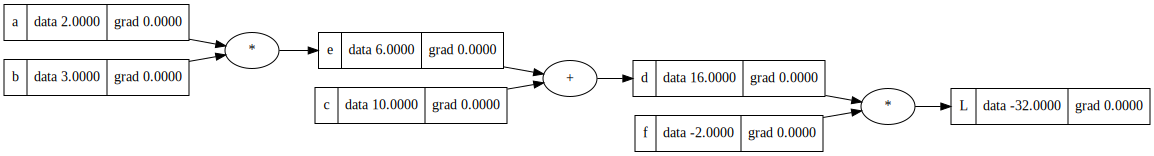

In [6]:
draw_dot(L)

dl/dc=dl/dd $\times$ dd/dc=-2*1 \\
dd/dc=1 \\
dd/de=1
dl/da=dl/de$\times$de/da=-2*b

In [7]:
f.grad=16.0
d.grad=-2
c.grad=-2
e.grad=-2
b.grad=-4
a.grad=-6
L._prev

{Value(data=-2.0), Value(data=16.0)}

In [8]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
d.data+=0.01*d.grad

e=a*b
e.label='e'
d=e+c
d.label='d'
f=Value(-2.0,label='f')
L=d*f
L.label='L'

In [9]:
L.grad=1.0

In [10]:
def lol():

  h=0.0001
  a=Value(2.0,label='a')
  b=Value( 3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b
  e.label='e'
  d=e+c
  d.label='d'
  f=Value(-2.0,label='f')
  L=d*f
  L.label='L'
  L1=L.data


  a=Value(2.0+h,label='a')
  b=Value( 3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b
  e.label='e'
  d=e+c
  d.label='d'
  f=Value(-2.0,label='f')
  L=d*f
  L.label='L'
  L2=L.data

  print((L2-L1)/h)

lol()

-6.000000000057071


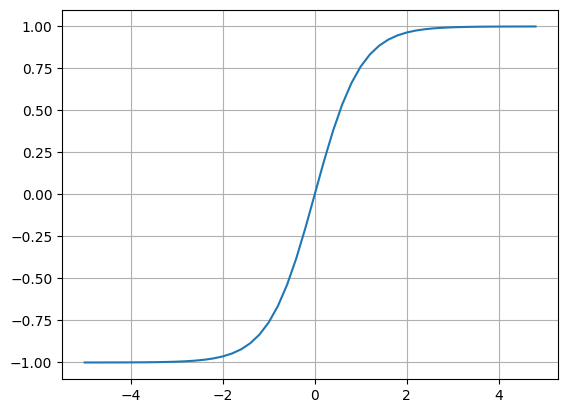

In [11]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

In [12]:
#inputs x1,x2
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
#weights
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1;x1w1.label='x1*w1'
x2w2=x2*w2;x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b ; n.label='n'
o=n.tanh();o.label='o'
o.backward()


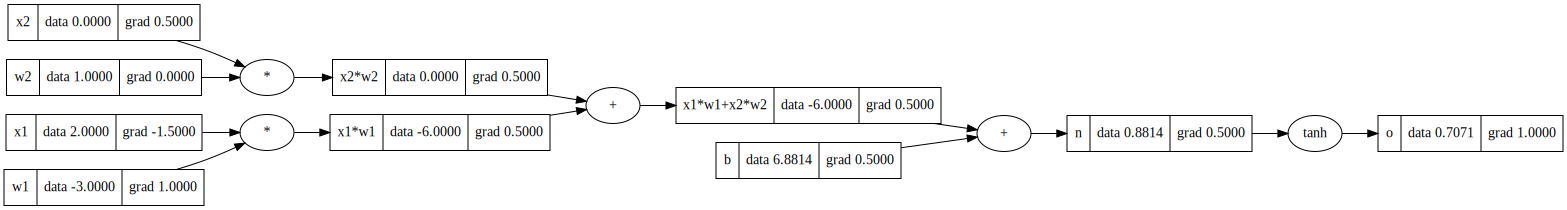

In [13]:
draw_dot(o)

In [14]:
o.backward()
#inputs x1,x2
x1=Value(2.0,label='x1')
x2=Value(0.0,label='x2')
#weights
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias
b=Value(6.8813735870195432,label='b')
x1w1=x1*w1;x1w1.label='x1*w1'
x2w2=x2*w2;x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1*w1+x2*w2'
n=x1w1x2w2+b ; n.label='n'
e=(2*n).exp()
o=(e-1)/(e+1);o.label='o'
o.backward()


In [15]:
import torch
x1=torch.Tensor([2.0]).double()     ; x1.requires_grad=True
x2=torch.Tensor([0.0]).double()     ; x2.requires_grad=True
w1=torch.Tensor([-3.0]).double()    ; w1.requires_grad=True
w2=torch.Tensor([1.0]).double()     ; w2.requires_grad=True
b=torch.Tensor([6.8813735870195432]).double()     ; b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2',x2.grad.item())
print('x1',x1.grad.item())
print('w2',w2.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737


In [16]:
o.data.item()

0.7071066904050358

In [17]:
class Neuron:

  def __init__(self,nin):  #nin: no. of inputs
    self.w=[Value(np.random.uniform(-1,1)) for _ in range(nin)]
    self.b=Value(np.random.uniform(-1,1))

  def __call__(self,x):

    act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out=act.tanh()
    return out

  def parameters(self):
    return self.w +[self.b]


class Layer:
  def __init__(self,nin,nout):
    self.neurons=[Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs=[n(x) for n in self.neurons]
    return   outs[0] if len(outs) == 1 else outs

  def parameters(self):
    params=[]
    for neuron in self.neurons:
      ps=neuron.parameters()
      params.extend(ps)
    return params


class MLP:
  def __init__(self,nin,nouts): #nouts is the sizes of each layer in MLP
    sz=[nin]+nouts
    self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x




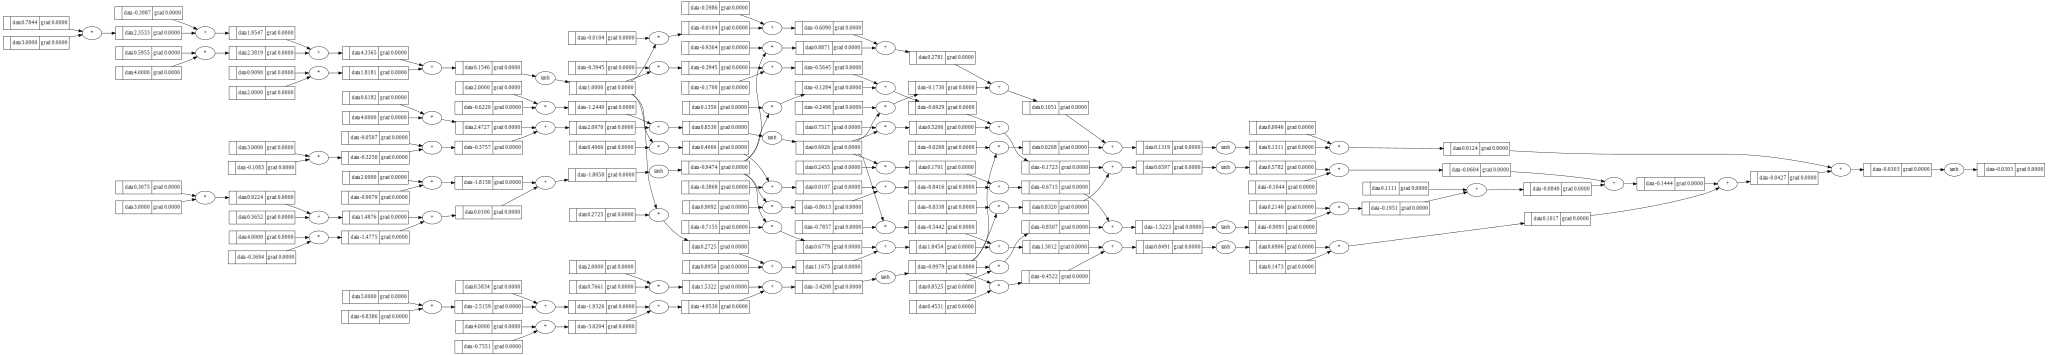

In [18]:
x=[3.0,4.0,2.0]
n=MLP(3,[4,4,1])
n(x)
draw_dot(n(x))

In [19]:
n.parameters()

[Value(data=0.7844414279115226),
 Value(data=0.595468780563619),
 Value(data=0.9090449278018458),
 Value(data=-0.39866204524707216),
 Value(data=0.3074565736965209),
 Value(data=-0.3693777732450647),
 Value(data=-0.9079228039750946),
 Value(data=0.5651893798369811),
 Value(data=-0.10833604870883784),
 Value(data=0.6181724153979586),
 Value(data=-0.6219794707200406),
 Value(data=-0.050693627331481084),
 Value(data=-0.8386360118610356),
 Value(data=-0.7551072954257545),
 Value(data=0.7660873855533012),
 Value(data=0.5833503519525407),
 Value(data=0.40656195430758446),
 Value(data=0.9091571208410711),
 Value(data=0.24553558438828538),
 Value(data=0.8525464400217022),
 Value(data=-0.3868154531900345),
 Value(data=-0.3944796863453761),
 Value(data=0.13557905607963305),
 Value(data=0.7516619535160107),
 Value(data=-0.8337712181923631),
 Value(data=-0.16998086012427827),
 Value(data=0.27247416216314013),
 Value(data=-0.7155198902293471),
 Value(data=-0.7856626921044567),
 Value(data=0.4531246

In [20]:
len(n.parameters()) #w,b for ever neuron and layer

41

In [21]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys=[1.0,-1.0,-1.0,1.0] #desired target

In [24]:
for k in range(100):

  ypred=[n(x) for x in xs]
  loss= sum(((yout-ygt)**2 for ygt,yout in zip(ys,ypred)), Value(0.0))  #forward pass

  for p in n.parameters():
    p.grad=0.0
  loss.backward() #backward pass

  for p in n.parameters():
    p.data+=-0.05*p.grad   #nudge to the minima

  #print(k,loss.data,ypred)

In [23]:
ypred

[Value(data=0.9608220607290051),
 Value(data=-0.9521490427243599),
 Value(data=-0.9707897153844531),
 Value(data=0.9586404022753041)]